In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 20.2 MB/s eta 0:00:00


**Imports**

In [ ]:
from google.colab import drive
import zipfile
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [ ]:
# torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader , Dataset,random_split
from torchmetrics.classification import BinaryAccuracy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_file_path = '/content/drive/MyDrive/Shop DataSet.zip'
extract_directory = '/content'

os.makedirs(extract_directory, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_directory)

In [ ]:
shop_lifters_path="/content/Shop DataSet/shop lifters"
shop_nonlifters_path="/content/Shop DataSet/non shop lifters"

**EDA on data**

In [ ]:
shop_lifters = [os.path.join(shop_lifters_path,i) for i in os.listdir(shop_lifters_path)]
shop_nonlifters = [os.path.join(shop_nonlifters_path,i) for i in os.listdir(shop_nonlifters_path)]

In [ ]:
print(len(shop_lifters))
print(len(shop_nonlifters))

324
528


In [ ]:
def number_frames(video_path):
  cap = cv2.VideoCapture(video_path)
  frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
  cap.release()
  return frame_count

In [ ]:
def number_fps(video_path):
  cap = cv2.VideoCapture(video_path)
  fps = int(cap.get(cv2.CAP_PROP_FPS))
  cap.release()
  return fps

In [ ]:
def find_min_frames(video_list):
    min_frames = float('inf')

    for video_path in video_list:
        frames = number_frames(video_path)
        if frames < min_frames:
            min_frames = frames

    print(f"The least number of frames: {min_frames}")

# Combine both lists if you want to check all videos
all_videos = shop_lifters + shop_nonlifters

find_min_frames(all_videos)

The least number of frames: 75


In [ ]:
shop_lifters_frames = [
    number_frames(i)
    for i in shop_lifters
]

shop_nonlifters_frames = [
    number_frames(i)
    for i in shop_nonlifters
]
shop_lifters_fps = [
    number_fps(i)
    for i in shop_lifters
]

shop_nonlifters_fps = [
    number_fps(i)
    for i in shop_nonlifters
]

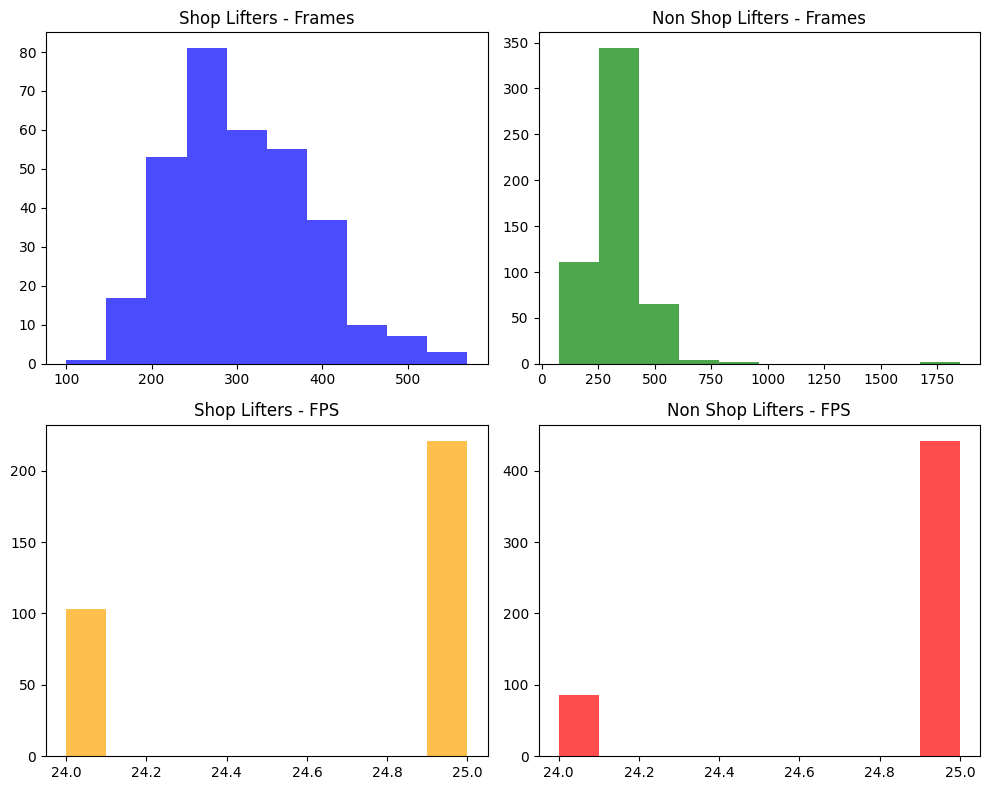

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(shop_lifters_frames, bins=10, color='blue', alpha=0.7)
axes[0, 0].set_title("Shop Lifters - Frames")

axes[0, 1].hist(shop_nonlifters_frames, bins=10, color='green', alpha=0.7)
axes[0, 1].set_title("Non Shop Lifters - Frames")

axes[1, 0].hist(shop_lifters_fps, bins=10, color='orange', alpha=0.7)
axes[1, 0].set_title("Shop Lifters - FPS")

axes[1, 1].hist(shop_nonlifters_fps, bins=10, color='red', alpha=0.7)
axes[1, 1].set_title("Non Shop Lifters - FPS")

plt.tight_layout()
plt.show()

**prepare data and splite data into train test**

In [ ]:
class Shop_Dataset(Dataset):
    def __init__(self, shop_lifters, shop_nonlifters, transform=None):
        self.shop_lifters = shop_lifters
        self.shop_nonlifters = shop_nonlifters
        self.transform = transform

    def __len__(self):
        return len(self.shop_lifters) + len(self.shop_nonlifters)

    def __getitem__(self, idx):

        if idx < len(self.shop_lifters):
            video_path = self.shop_lifters[idx]
            label = 1
        else:
            video_path = self.shop_nonlifters[idx - len(self.shop_lifters)]
            label = 0

        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        indices = np.linspace(0, total_frames - 1, 16, dtype=int)
        frames = []

        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret:
                continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # Convert the NumPy array to a PIL Image before applying transforms
            frame = Image.fromarray(frame)
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)

        cap.release()

        frames = torch.stack(frames)

        label = torch.tensor(label, dtype=torch.long)

        return frames, label

In [ ]:
# frame size (576, 704, 3)
tranform = transforms.Compose([
    transforms.Resize((224 , 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

In [ ]:
dataset = Shop_Dataset(shop_lifters, shop_nonlifters, transform=tranform)

train_size = int(0.8 * len(dataset))
val_size=int(0.1 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_dataset,val_dataset,test_dataset = random_split(dataset, [train_size,val_size,test_size])

##### Embedding for videos

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# Load pre-trained ResNet50
base_model = models.resnet50(pretrained=True)
# Remove the classification head
feature_extractor = nn.Sequential(*list(base_model.children())[:-1])
feature_extractor.eval()
feature_extractor.cuda()  # if using GPU

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [ ]:
from torch.utils.data import DataLoader
import torch.nn.functional as F

@torch.no_grad()
def extract_video_embedding(frames, model, device):

    frames = frames.to(device, non_blocking=True)
    feats = model(frames)                     # (T, 2048, 1, 1)
    feats = feats.squeeze(-1).squeeze(-1)     # (T, 2048)
    video_embedding = feats.mean(dim=0)       # (2048,)
    return video_embedding

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = feature_extractor.to(device).eval()

train_embeddings = []
val_embeddings = []

with torch.no_grad():
    for vid, label in train_dataset:
        # Move all frames to GPU
        vid = vid.to(device)  # shape: [num_frames, 3, H, W]

        # Forward all frames in one go
        features = feature_extractor(vid)
        features = features.view(features.size(0), -1)
        train_embeddings.append((features.cpu(), label))

    for vid, label in val_dataset:
        vid = vid.to(device)
        features = feature_extractor(vid)
        features = features.view(features.size(0), -1)
        val_embeddings.append((features.cpu(), label))

    print("✅ Done extracting validation embeddings!")

print(f"\nNumber of train videos embedded: {len(train_embeddings)}")
print(f"Number of validation videos embedded: {len(val_embeddings)}")
print(f"Shape of first train video feature: {train_embeddings[0][0].shape}")

✅ Done extracting validation embeddings!

Number of train videos embedded: 681
Number of validation videos embedded: 85
Shape of first train video feature: torch.Size([16, 2048])


In [ ]:
import torch.nn.functional as F

train_emb = torch.stack([emb.mean(dim=0) for emb, _ in train_embeddings])
val_emb   = torch.stack([emb.mean(dim=0) for emb, _ in val_embeddings])

# (num_val, 1, embed_dim) vs (1, num_train, embed_dim)
similarity_matrix = F.cosine_similarity(
    val_emb.unsqueeze(1),
    train_emb.unsqueeze(0),
    dim=-1
)

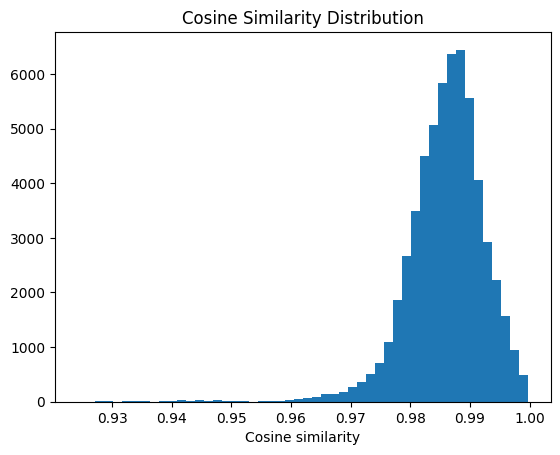

In [ ]:
import matplotlib.pyplot as plt

plt.hist(similarity_matrix.flatten().numpy(), bins=50)
plt.title("Cosine Similarity Distribution")
plt.xlabel("Cosine similarity")
plt.show()

In [ ]:
# Filter Highly similar videos

threshold = 0.996

# find training videos that are highly similar to any validation video
highly_similar_mask = (similarity_matrix > threshold).any(dim=0)

filtered_train_embeddings = [
    (emb, label) for i, (emb, label) in enumerate(train_embeddings)
    if not highly_similar_mask[i]
]

print(f"\nRemoved {highly_similar_mask.sum().item()} training videos "
      f"that were too similar to validation set.")
print(f"Remaining training videos: {len(filtered_train_embeddings)}")


Removed 559 training videos that were too similar to validation set.
Remaining training videos: 122


In [ ]:
from torch.utils.data import Subset, DataLoader

# Get indices of filtered videos
filtered_indices = [i for i, (emb, label) in enumerate(train_embeddings) if not highly_similar_mask[i]]

# Create a Subset of the original training dataset using these indices
filtered_train_dataset = Subset(train_dataset, filtered_indices)

In [ ]:
print(f"size of train dataset is {len(train_dataset)}")
print(f"size of val dataset is {len(val_dataset)}")
print(f"size of test dataset is {len(test_dataset)}")

size of train dataset is 681
size of val dataset is 85
size of test dataset is 86


In [ ]:
train_loader = DataLoader(filtered_train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

**3D CNN** Model Architecture

In [ ]:
class CNN3D(nn.Module):
    def __init__(self, num_classes=2):
        super(CNN3D, self).__init__()

        self.conv1 = nn.Conv3d(3, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool3d(2)

        self.conv2 = nn.Conv3d(64, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool3d(2)

        self.conv3 = nn.Conv3d(128, 256, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool3d(2)

        self.fc1 = None
        self.fc2 = None
        self.num_classes = num_classes

    def forward_features(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = x.view(x.size(0), -1)

        # Lazy init for fc layers
        if self.fc1 is None:
            in_features = x.size(1)
            self.fc1 = nn.Linear(in_features, 512).to(x.device)
            self.fc2 = nn.Linear(512, self.num_classes).to(x.device)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
model = CNN3D()
print(model)

CNN3D(
  (conv1): Conv3d(3, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (pool1): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (pool2): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv3d(128, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (pool3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
import torch.optim as optim

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

**Train The Model**

In [ ]:
from tqdm import tqdm

num_epochs = 20
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(num_epochs):
    # -------------------- TRAIN --------------------
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=True)
    for frames, labels in loop:
        frames, labels = frames.to(device), labels.to(device)

        frames = frames.permute(0, 2, 1, 3, 4)

        outputs = model(frames)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    avg_train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # -------------------- VALIDATION --------------------
    model.eval()
    val_loss = 0.0
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for frames, labels in val_loader:
            frames, labels = frames.to(device), labels.to(device)
            frames = frames.permute(0, 2, 1, 3, 4)

            outputs = model(frames)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    # -------------------- LOG RESULTS --------------------
    print(f"\nEpoch [{epoch+1}/{num_epochs}] Summary:")
    print(f"  Train → Loss: {avg_train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"  Val   → Loss: {avg_val_loss:.4f} | Acc: {val_acc:.2f}%\n")

Epoch [1/20]: 100%|██████████| 16/16 [01:52<00:00,  7.01s/it, acc=77.9, loss=0.608]



Epoch [1/20] Summary:
  Train → Loss: 0.4215 | Acc: 77.87%
  Val   → Loss: 0.5296 | Acc: 68.24%



Epoch [2/20]: 100%|██████████| 16/16 [01:50<00:00,  6.93s/it, acc=91, loss=0.761]



Epoch [2/20] Summary:
  Train → Loss: 0.2510 | Acc: 90.98%
  Val   → Loss: 0.6223 | Acc: 71.76%



Epoch [3/20]: 100%|██████████| 16/16 [01:51<00:00,  6.99s/it, acc=93.4, loss=0.0176]


...


Epoch [18/20] Summary:
  Train → Loss: 0.0171 | Acc: 100.00%
  Val   → Loss: 0.4883 | Acc: 89.41%



Epoch [19/20]: 100%|██████████| 16/16 [01:52<00:00,  7.03s/it, acc=100, loss=0.000504]



Epoch [19/20] Summary:
  Train → Loss: 0.0084 | Acc: 100.00%
  Val   → Loss: 0.5283 | Acc: 90.59%



Epoch [20/20]: 100%|██████████| 16/16 [01:51<00:00,  6.97s/it, acc=99.2, loss=0.00264]



Epoch [20/20] Summary:
  Train → Loss: 0.0207 | Acc: 99.18%
  Val   → Loss: 0.5347 | Acc: 89.41%



In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Evaluation ---
model.eval()
y_true, y_pred = [], []
val_loss = 0.0

with torch.no_grad():
    loop = tqdm(test_loader, desc="Evaluating", leave=False)
    for frames, labels in loop:
        frames, labels = frames.to(device), labels.to(device)

        frames = frames.permute(0, 2, 1, 3, 4)

        outputs = model(frames)
        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# --- Compute Metrics ---
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("📊 Evaluation Results:")
print(f"Loss:      {val_loss/len(val_loader):.4f}")
print(f"Accuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall:    {rec*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")

📊 Evaluation Results:
Loss:      0.4946
Accuracy:  93.02%
Precision: 89.66%
Recall:    89.66%
F1 Score:  89.66%


In [ ]:
# Save Model
torch.save(model.state_dict(), "cnn3d_best1.pth")